In [ ]:
#Leo Murch
#P2
#09/18/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
print('Problem 1')
#use the same on as in hw4,
#np.random.normal(55, 13, N)

Problem 1


In [84]:
print('Problem 2')
#do it for 10 times
N_dim = (10,10)
sample = np.random.normal(55, 13, N_dim) #make a 10x10 for the full sample

"""
data_sample = [] #empty list to put the 10x3
i = 0
for row in sample:
    #append mean, std, and the row number
    mu = np.mean(row)
    sigma = np.std(row)
    data_sample.append([i, mu, sigma])
    i+=1 #index for row (probably could do with for i in blah blah but
    #row in sample is easier for writing the mean and std)
print(data_sample)
"""
#ill try w/out for loop
sample_num = (np.arange(10))
means = np.mean(sample, axis = 1)
stdevs = np.std(sample, axis = 1)
data_sample = np.column_stack((sample_num, means, stdevs))

#stole column_stack from ai, didnt know of it (but now i do!)
print(data_sample)


Problem 2
[[ 0.         58.56379034 11.7934924 ]
 [ 1.         52.08312075  9.80045523]
 [ 2.         46.50734456 10.32376617]
 [ 3.         57.51846209 12.17077806]
 [ 4.         62.72650492 15.46685812]
 [ 5.         56.55322904 15.36649158]
 [ 6.         58.15228474 12.35047187]
 [ 7.         52.06176627 11.46009653]
 [ 8.         53.59677333 10.76432364]
 [ 9.         52.49805482 12.07661698]]


In [85]:
print('Problem 3')
#prompt:
#for problem 3, ignore my attempts and do this using np.random.normal()
#and then a picture of problem 1 and 2

#ai code:
mu = 55
sigma = 13
N = 10
n_samples = 10
# 10 independent samples, 10 draws each
draws = np.random.normal(mu, sigma, size=(n_samples, N))
data_sample = np.column_stack((
    np.arange(n_samples),          # sample number 0–9
    np.mean(draws, axis=1),        # mean of each sample
    np.std(draws, axis=1),         # std of each sample
))
print(data_sample)

Problem 3
[[ 0.         61.30263662 12.74535258]
 [ 1.         58.11807431  8.83818091]
 [ 2.         50.19391031 14.94206539]
 [ 3.         52.38646307 20.29650618]
 [ 4.         49.91514551  8.95964519]
 [ 5.         61.77112266 10.04750821]
 [ 6.         55.55522202 16.88775988]
 [ 7.         47.22996131  8.5444833 ]
 [ 8.         49.08119783 16.81105321]
 [ 9.         51.48874156 13.8003773 ]]


In [86]:
print('Problem 4')
#use np.savetxt, takes the name, data, format, and delimiter
#also has a header field so I can do it simply
np.savetxt(
    'p2_aleonav_problem3_data.txt',
    data_sample,
    fmt = ['%d', '%f', '%f'], #its crazy that it knows and it works so easy
    delimiter = ' ',
    header = f"Number of Draws N = {N}"
)

Problem 4


In [87]:

print('Problem 5')
#call the code again to get the 5 different draws;
#actually lets try making a function to do it why not
def sample_pull(N, sigma, mu):
    """pulls from a gaussian distribution 10 times with specified values of:
    sigma,
    mu,
    # of Draws per sample of N.

    then assembles each sample into a row with:
    pull#, sample mean, sample stdev

    returns this 10 x 3 array.
    """
    sample = np.random.normal(mu, sigma, (10, N))
    sample_num = (np.arange(10))
    means = np.mean(sample, axis = 1)
    stdevs = np.std(sample, axis = 1)
    data_sample = np.column_stack((sample_num, means, stdevs))
    
    return data_sample


#need to also open the file into append mode since np.savetxt will overwrite.
N_arr = [100,1000,10000,100000,1000000]
with open('p2_aleonav_problem3_data.txt', 'a') as f:
    for item in N_arr:
        result_pull = sample_pull(item, 13, 55)
        #now can do np.savetxt since we're in append mode
        np.savetxt(
            f,
            result_pull,
            fmt = ['%d', '%f', '%f'],
            delimiter = ' ',
            header = f"Number of Draws N = {item}"
        )
#nice it worked
f.close()

Problem 5


In [88]:
print('Problem 6')
#i used ai on this part, prompting it with the prompt of problem 6 and asking
#it to explain in detail how the filei/o works, since i'm not that familiar with it.

#i'll adapt some of its code into mine as i read it to understand:
path = 'p2_aleonav_problem3_data.txt'

#make dummy arrays to fill in with the values read.
Ns = []
stds_of_means = []
current_N = None
means = []

with open(path, 'r') as f:
    for line in f:
        line = line.strip() #gets rid of whitespaces
        if not line:
            continue

        if line.startswith('#'): #to see if its a title specifying the N size
            if current_N is not None and means:#and means is len(means) > 0
                Ns.append(current_N)
                stds_of_means.append(np.std(means))
            
            current_N = int(line.split('=')[-1]) #Number of Draws N = 10
            means = [] #empty again
        else:
            cols = line.split()
            means.append(float(cols[1])) #where the means sit in the file

#for the last block in the file w/ no header after it ends
if current_N is not None and means:
    Ns.append(current_N)
    stds_of_means.append(np.std(means))

#get ready to append to the file, print too.
summary = np.column_stack((Ns, stds_of_means))
print('#Sample size\tStd. dev. of mean')
for N, s in zip(Ns, stds_of_means): #i'm not that sure of what this part is,
    #but it works to format it well.
    print(f'{N:<21} {s:.1f}') #the <21 is to get it consistently lined up in the print
f.close()
#now append
with open(path, 'a') as f:
    np.savetxt(
        f,
        summary,
        fmt=['%d', '%.1f'],
        delimiter=' ', #to get necessary spacing
        header='Sample size\tStd. dev. of mean',
    )

f.close()

#had some trouble getting the lining up to work, but i finally got it now.
#everything looks to trend down as the N's go up, which makes sense.

Problem 6
#Sample size	Std. dev. of mean
10                    4.9
100                   1.2
1000                  0.3
10000                 0.1
100000                0.0
1000000               0.0


Problem 7


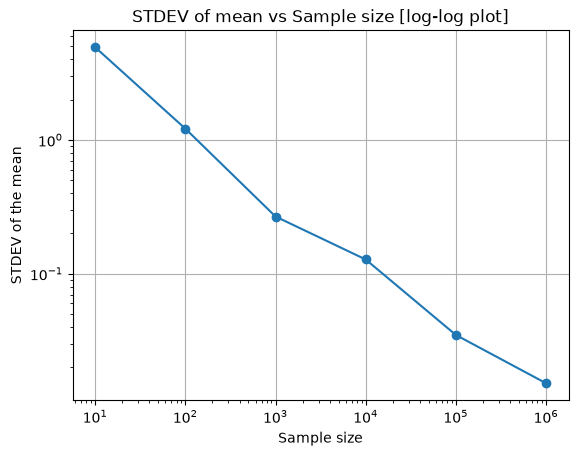

In [89]:
print('Problem 7')
#i remember talking about this part in class with the log part
#plt apparently has a function plt.loglog() to do this

plt.loglog(Ns, stds_of_means, 'o-') #o- gives both a scatter and lines between them
#which is nice
plt.xlabel('Sample size')
plt.ylabel('STDEV of the mean')
plt.title('STDEV of mean vs Sample size [log-log plot]')
plt.grid()
plt.savefig('p2_aleonav_problem7_graph1.png')
plt.show()